# Parse Training History Notebook

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
from pathlib import Path

In [ ]:
base_path = Path.cwd() / "data_raw/all_garmin_data/DI_CONNECT/DI-Connect-Metrics"

paths = [
    base_path / 'TrainingHistory_20210708_20211016_48001360.json',
    base_path / 'TrainingHistory_20211016_20220124_48001360.json',
    base_path / 'TrainingHistory_20220124_20220504_48001360.json',
    base_path / 'TrainingHistory_20220504_20220812_48001360.json',
    base_path / 'TrainingHistory_20220812_20221120_48001360.json',
    base_path / 'TrainingHistory_20221120_20230228_48001360.json',
    base_path / 'TrainingHistory_20230228_20230608_48001360.json',
    base_path / 'TrainingHistory_20230608_20230916_48001360.json',
    base_path / 'TrainingHistory_20230916_20231225_48001360.json',
    base_path / 'TrainingHistory_20231225_20240403_48001360.json',
    base_path / 'TrainingHistory_20240403_20240712_48001360.json',
    base_path / 'TrainingHistory_20240712_20241020_48001360.json',
    base_path / 'TrainingHistory_20241020_20250128_48001360.json',
    base_path / 'TrainingHistory_20250128_20250508_48001360.json',
    base_path / 'TrainingHistory_20250508_20250816_48001360.json',
    base_path / 'TrainingHistory_20250816_20251124_48001360.json',
    base_path / 'TrainingHistory_20251124_20260304_48001360.json',
    base_path / 'TrainingHistory_20260304_20260612_48001360.json'
]

In [9]:
training_history_df = pd.DataFrame()

for path in paths:
    with open(path, 'r') as f:
        data = json.load(f)
        df = pd.DataFrame(data)

        training_history_df = pd.concat([training_history_df, df], ignore_index=True)  

print(training_history_df.head(5))

   userProfilePK calendarDate    deviceId              timestamp    sport  \
0       48001360   2021-07-14  3304525890  2021-07-14T04:00:00.0  RUNNING   
1       48001360   2021-07-14  3304525890  2021-07-14T19:53:09.0  RUNNING   
2       48001360   2021-07-14  3304525890  2021-07-15T01:15:29.0  RUNNING   
3       48001360   2021-07-15  3304525890  2021-07-15T04:00:00.0  RUNNING   
4       48001360   2021-07-16  3304525890  2021-07-16T04:00:02.0  RUNNING   

  subSport  weeklyTrainingLoadSum  loadTunnelMin  loadTunnelMax  \
0  GENERIC                  300.0          220.0          503.0   
1  GENERIC                  326.0          261.0          607.0   
2  GENERIC                  484.0          391.0          911.0   
3  GENERIC                  362.0          330.0          735.0   
4  GENERIC                  362.0          261.0          607.0   

  trainingStatus fitnessLevelTrend loadLevelTrend  \
0    MAINTAINING         NO_CHANGE      NO_CHANGE   
1    MAINTAINING         NO_

In [10]:
drop_cols = [
    'userProfilePK',
    'deviceId'
]

training_history_df.drop(columns=drop_cols, inplace=True)

In [14]:
print(training_history_df.info())
print(training_history_df.describe())
print(training_history_df.sample(5))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2725 entries, 0 to 2724
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   calendarDate                   2725 non-null   object 
 1   timestamp                      2725 non-null   object 
 2   sport                          2706 non-null   object 
 3   subSport                       2706 non-null   object 
 4   weeklyTrainingLoadSum          1290 non-null   float64
 5   loadTunnelMin                  1290 non-null   float64
 6   loadTunnelMax                  1290 non-null   float64
 7   trainingStatus                 2725 non-null   object 
 8   fitnessLevelTrend              2725 non-null   object 
 9   loadLevelTrend                 1290 non-null   object 
 10  trainingStatus2FeedbackPhrase  1435 non-null   object 
dtypes: float64(3), object(8)
memory usage: 234.3+ KB
None
       weeklyTrainingLoadSum  loadTunnelMin  loadTunne

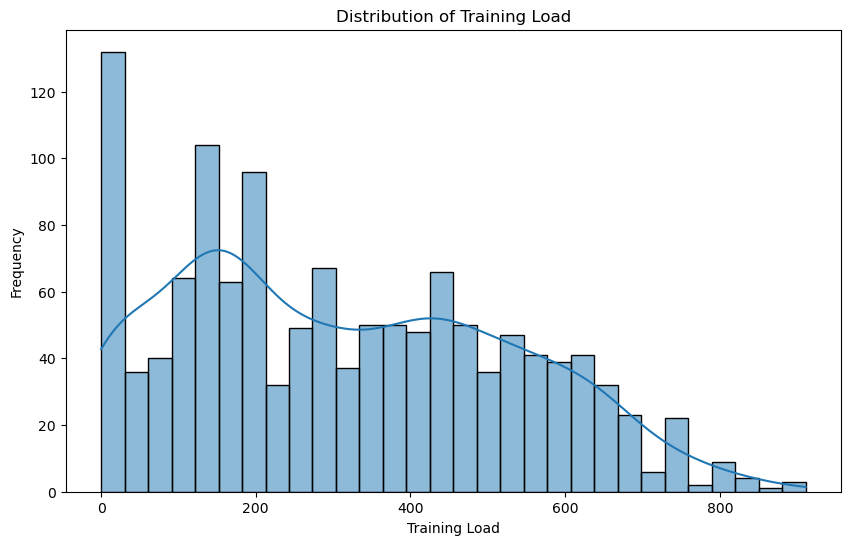

In [21]:
# Plot the distribution of training loads
plt.figure(figsize=(10, 6))
sns.histplot(training_history_df['weeklyTrainingLoadSum'], bins=30, kde=True)
plt.title('Distribution of Training Load')
plt.xlabel('Training Load')
plt.ylabel('Frequency')
plt.show()

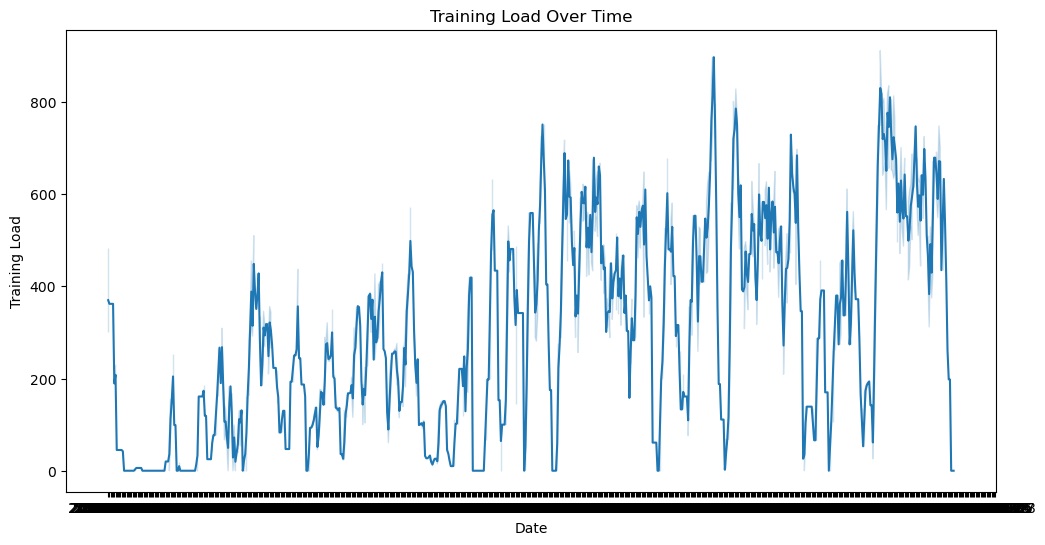

In [25]:
# Plot of training load over time
plt.figure(figsize=(12, 6))
sns.lineplot(x='calendarDate', y='weeklyTrainingLoadSum', data=training_history_df)
plt.title('Training Load Over Time')
plt.xlabel('Date')
plt.ylabel('Training Load')
plt.show()

In [ ]:
# Save the dataframe to a new parquet file
output_path = Path.cwd() / 'data_processed/training_history_v1.parquet'
training_history_df.to_parquet(
    output_path,
    index=False
)